# Notebook 2: Exploratory Data Analysis

## Objective
Explore the distribution and evolution of key banking indicators across European banks and countries. Identify patterns, outliers and potential vulnerabilities in the euro area banking sector.

In [20]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("banking_indicators_clean.csv")
df['Period'] = pd.to_datetime(df['Period'])

# Check
print(df.shape)
print(df.dtypes)

(465, 8)
LEI_Code                object
Period          datetime64[ns]
CET1_capital           float64
RWA                    float64
total_assets           float64
Name                    object
Country                 object
CET1_ratio             float64
dtype: object


## 1. Distribution of CET1 Ratio
The CET1 Ratio is the primary indicator for bank capital adequacy. The regulatory minimum is 8%. Banks below 11% are considered to have limited capital buffers and may be more vulnerable to shocks.

<function matplotlib.pyplot.show(close=None, block=None)>

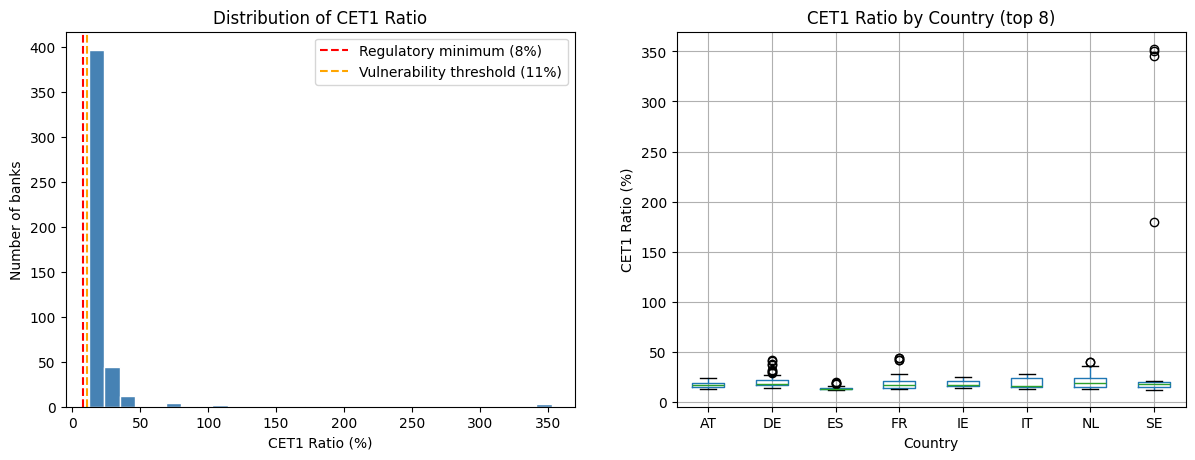

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
axes[0].hist(df['CET1_ratio'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=8, color='red', linestyle='--', label='Regulatory minimum (8%)')
axes[0].axvline(x=11, color='orange', linestyle='--', label='Vulnerability threshold (11%)')
axes[0].set_title('Distribution of CET1 Ratio')
axes[0].set_xlabel('CET1 Ratio (%)')
axes[0].set_ylabel('Number of banks')
axes[0].legend()

# Boxplot by country (top 8 countries by number of observations)
top_counties = df['Country'].value_counts().head(8).index
df_top = df[df['Country'].isin(top_counties)]
df_top.boxplot(column='CET1_ratio', by='Country', ax=axes[1], figsize=(14,5))
axes[1].set_title('CET1 Ratio by Country (top 8)')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('CET1 Ratio (%)')
plt.suptitle('')

plt.tight_layout
plt.savefig('plot_01_cet1_distribution.png', dpi=150, bbox_inches='tight')
plt.show

In [22]:
# Investigate outliers
print(df[df['CET1_ratio']>50][['Name', 'Country', 'Period', 'CET1_ratio', 'RWA', 'total_assets']].sort_values('CET1_ratio', ascending=False))

                            Name Country     Period  CET1_ratio          RWA  \
342         Kommuninvest - Grupp      SE 2025-06-01  352.660867   302.298752   
341         Kommuninvest - Grupp      SE 2025-03-01  350.701893   312.535462   
340         Kommuninvest - Grupp      SE 2024-12-01  345.909054   298.711645   
339         Kommuninvest - Grupp      SE 2024-09-01  180.037196   576.266215   
75             Kuntarahoitus Oyj      FI 2024-12-01  107.709331  1528.307043   
74             Kuntarahoitus Oyj      FI 2024-09-01  104.275643  1529.436007   
76             Kuntarahoitus Oyj      FI 2025-03-01   95.735410  1688.901365   
77             Kuntarahoitus Oyj      FI 2025-06-01   89.373533  1850.629757   
405  THE BANK OF NEW YORK MELLON      BE 2024-09-01   79.581307  5118.770217   
407  THE BANK OF NEW YORK MELLON      BE 2025-03-01   77.189805  5825.471755   
406  THE BANK OF NEW YORK MELLON      BE 2024-12-01   76.762054  5810.310772   
408  THE BANK OF NEW YORK MELLON      BE

## 2. Outlier treatment
Some institutions showed extremely high CET1 ratios (above 50%), mainly due to very low levels of Risk-Weighted Assets relative to capital. These observations correspond to specialized standard institutions with non-standard business models and would distort the exploratory analysis.

To improve the interpretability of the visualisations and summary statistics, observations with CET1 ratios above 50% are excluded from the dataset.

In [28]:
# Remove extreme CET1 ratio outliers
df = df[df['CET1_ratio'] < 50]

# Check updated distribution
print(df.shape)
print(df['CET1_ratio'].describe())

(453, 8)
count    453.000000
mean      18.582947
std        5.324165
min       12.191369
25%       15.201716
50%       17.624883
75%       20.126479
max       44.320459
Name: CET1_ratio, dtype: float64


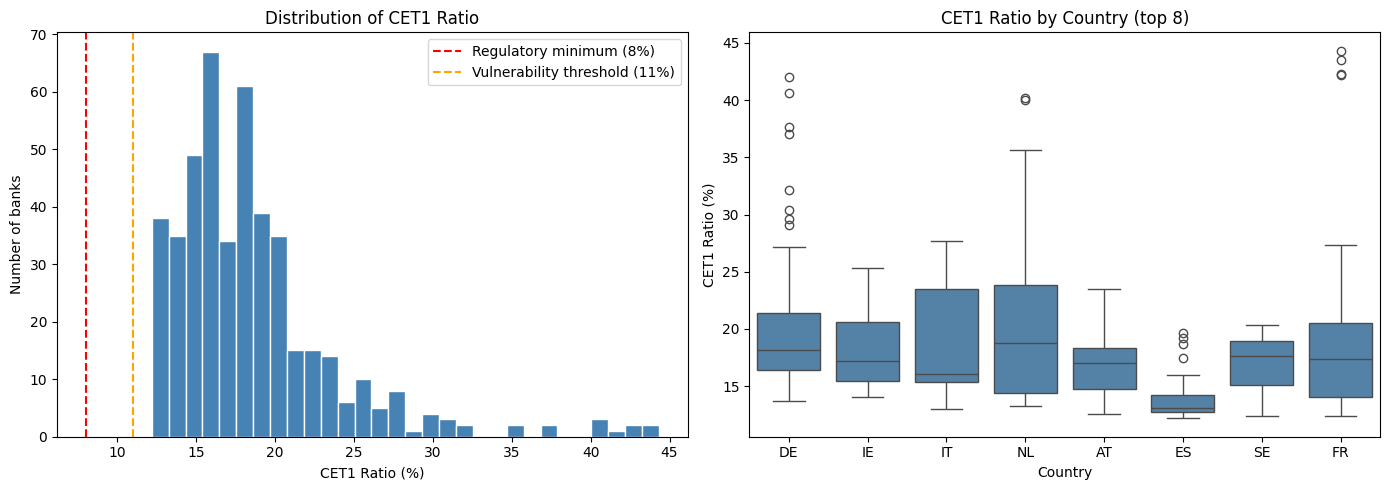

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['CET1_ratio'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=8, color='red', linestyle='--', label='Regulatory minimum (8%)')
axes[0].axvline(x=11, color='orange', linestyle='--', label='Vulnerability threshold (11%)')
axes[0].set_title('Distribution of CET1 Ratio')
axes[0].set_xlabel('CET1 Ratio (%)')
axes[0].set_ylabel('Number of banks')
axes[0].legend()

# Boxplot by country (top 8 countries)
top_countries = df['Country'].value_counts().head(8).index
df_top = df[df['Country'].isin(top_countries)]
sns.boxplot(data=df_top, x='Country', y='CET1_ratio', ax=axes[1], color='steelblue')
axes[1].set_title('CET1 Ratio by Country (top 8)')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('CET1 Ratio (%)')

plt.tight_layout()
plt.savefig('plot_01_cet1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Key observations

**Left panel, Distribution:**
The CET1 ratio distribution is right-skewed, with most banks clustered between 13% and 22%. No bank falls below the regulatory minimum of 8%, confirming the overall resilience of the European banking sector. The bulk of observations sit well above the 11% vulnerability threshold.

**Right panel, Country comparison:**
- **Austria (AT)** shows the lowest median CET1 ratio (~14%), suggesting relatively tighter capital buffers
- **Netherlands (NL) and Italy (IT)** show higher medians (~19-23%) with significant dispersion
- **Spain (ES)** has a very tight distribution with low median (~14%), but with some outliers above 19%
- **Ireland (IE), France (FR), Sweden (SE)** cluster around 17-20%
- Germany (DE) shows high dispersion — reflecting the heterogeneity of its banking sector (large commercial banks vs smaller institutions)

## 3. Time-series Analysis: CET1 Evolution by Country
We now analyse how CET1 ratios have evolved across the four reference periods.
This allows us to identify trends and potential deterioration signals at the country level.

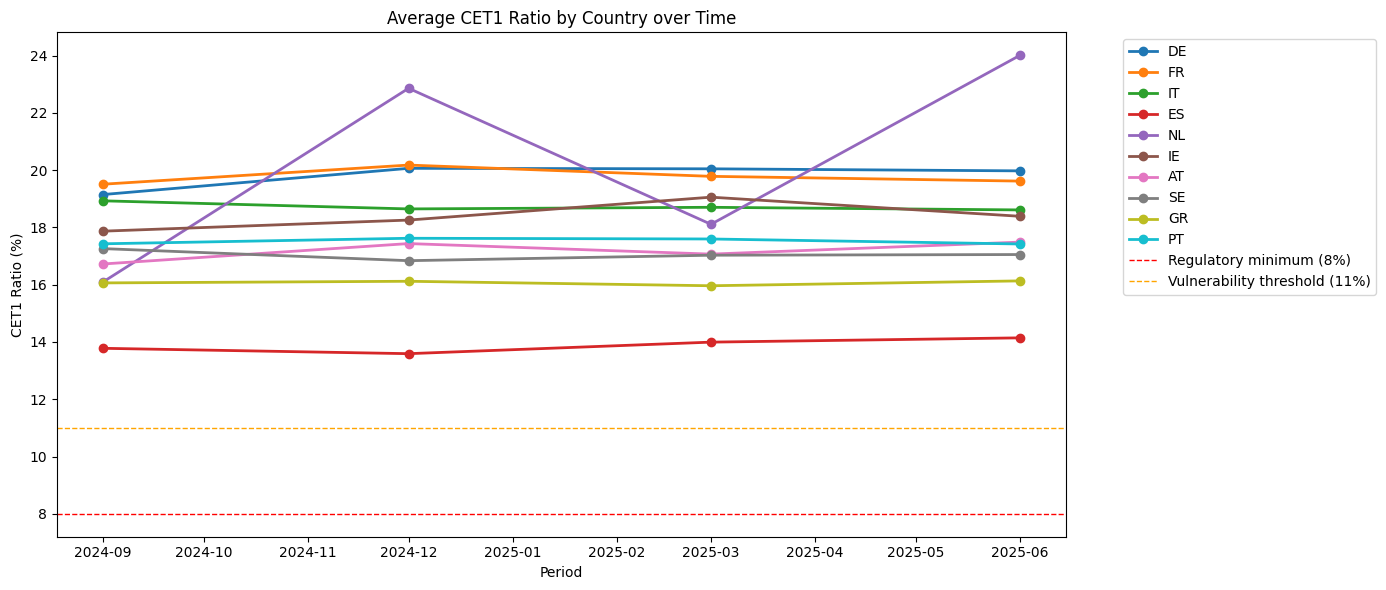

In [31]:
# Average CET1 ratio by country and period
top_countries = ['DE', 'FR', 'IT', 'ES', 'NL', 'IE', 'AT', 'SE', 'GR', 'PT']
df_top = df[df['Country'].isin(top_countries)]

cet1_time = df_top.groupby(['Period', 'Country'])['CET1_ratio'].mean().reset_index()

plt.figure(figsize=(14, 6))
for country in top_countries:
    data = cet1_time[cet1_time['Country'] == country]
    plt.plot(data['Period'], data['CET1_ratio'], marker='o', label=country, linewidth=2)

plt.axhline(y=8, color='red', linestyle='--', linewidth=1, label='Regulatory minimum (8%)')
plt.axhline(y=11, color='orange', linestyle='--', linewidth=1, label='Vulnerability threshold (11%)')
plt.title('Average CET1 Ratio by Country over Time')
plt.xlabel('Period')
plt.ylabel('CET1 Ratio (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_02_cet1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Key observations

All countries remain well above both the regulatory minimum (8%) and the vulnerability threshold (11%) throughout the entire period, confirming broad resilience across the euro area banking sector.

**Notable trends:**
- **Spain (ES)** consistently shows the lowest CET1 ratio (~14%), with limited improvement over time — the most closely watched country
- **Greece (GR)** also remains at the lower end (~16%), reflecting its historically weaker banking sector
- **Netherlands (NL)** shows high volatility — a sharp spike in Q4 2024 followed by a drop in Q1 2025 and recovery in Q2 2025. This warrants further investigation at the bank level
- **Germany (DE) and France (FR)** show stable and solid ratios around 20%, consistent with their role as core euro area banking systems
- **Portugal (PT) and Ireland (IE)** show gradual improvement, reflecting continued post-crisis recovery

## 4. Bank-level Vulnerability Analysis
We identify individual banks with the lowest CET1 ratios across all periods. These institutions represent the most capital-constrained banks in the sample and are the primary candidates for the Early Warning System.

                                     Name Country  CET1_ratio  total_assets
0                         CaixaBank, S.A.      ES   12.249989  5.798973e+05
1                             BNP Paribas      FR   12.458721  2.573934e+06
2                          BAWAG Group AG      AT   12.548430  7.276514e+04
3                         Bankinter, S.A.      ES   12.574219  1.317730e+05
4                              RCI Banque      FR   12.729033  7.316897e+04
5                  Intesa Sanpaolo S.p.A.      IT   12.971478  7.705184e+05
6                   Banco Santander, S.A.      ES   12.984878  1.797910e+06
7                 Banco de Sabadell, S.A.      ES   13.059745  2.523766e+05
8       Abanca Corporacion Bancaria, S.A.      ES   13.224918  8.197400e+04
9                          ING Groep N.V.      NL   13.261921  1.086760e+06
10  Banco Bilbao Vizcaya Argentaria, S.A.      ES   13.340270  7.469548e+05
11                  Société générale S.A.      FR   13.539140  1.380480e+06
12     Banqu

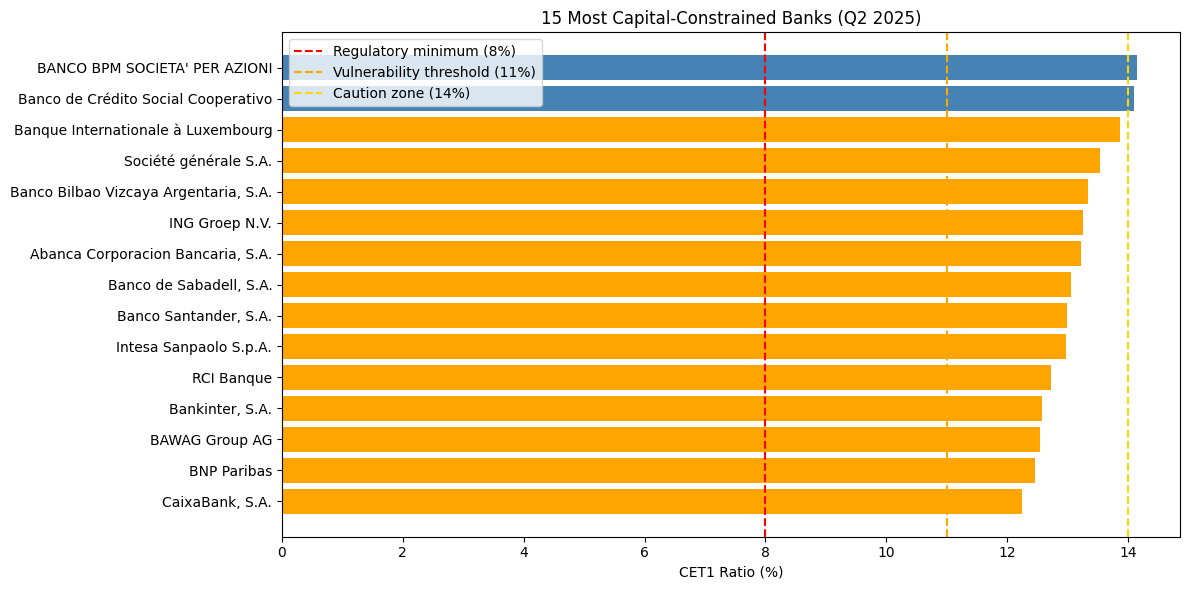

In [33]:
# Latest period only
latest = df[df['Period'] == df['Period'].max()]

# Bottom 15 banks
bottom_banks = latest.nsmallest(15, 'CET1_ratio')[['Name', 'Country', 'CET1_ratio', 'total_assets']].reset_index(drop=True)
print(bottom_banks)

# Plot
plt.figure(figsize=(12,6))
colors = ['red' if x<11 else 'orange' if x<14 else 'steelblue' for x in bottom_banks['CET1_ratio']]
plt.barh(bottom_banks['Name'], bottom_banks['CET1_ratio'], color=colors)
plt.axvline(x=8, color='red', linestyle='--', label='Regulatory minimum (8%)')
plt.axvline(x=11, color='orange', linestyle='--', label='Vulnerability threshold (11%)')
plt.axvline(x=14, color='gold', linestyle='--', label='Caution zone (14%)')
plt.title('15 Most Capital-Constrained Banks (Q2 2025)')
plt.xlabel('CET1 Ratio (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_03_vulnerable_banks.png', dpi=150, bbox_inches='tight')
plt.show()


### Key observations
All 15 most capital-constrained banks remain above the regulatory minimum (8%) and the vulnerability threshold (11%), confirming no immediate supervisory concern.
However, 13 out of 15 banks fall within the caution zone (below 14%), suggesting limited capital buffers in adverse scenarios.

Spanish banks dominate the list, consistent with the country-level analysis.
Notable systemically important institutions (BNP Paribas, Société Générale, Intesa Sanpaolo, ING) also appear, which is relevant from a macroprudential perspective given their size and interconnectedness.

## 5. Correlation Analysis
We examine the relationships between key banking indicators to identify potential multicollinearity and understand which variables move together.
This will inform the feature selection for the clustering and early warning model.

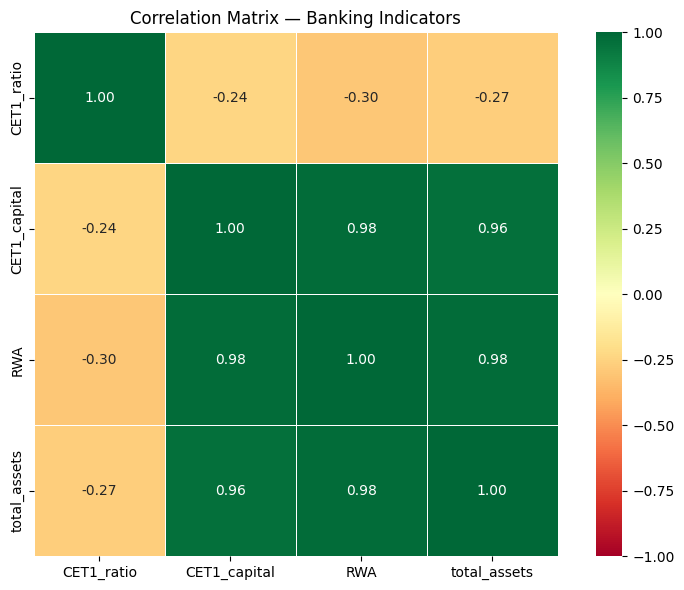

In [34]:
# Select numeric indicators
corr_vars = ['CET1_ratio', 'CET1_capital', 'RWA', 'total_assets']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix — Banking Indicators')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Key observations

**CET1_capital, RWA and total_assets are almost perfectly correlated (0.96-0.98).**
This is expected: larger banks naturally hold more capital in absolute terms and have higher risk-weighted assets. These three variables essentially measure bank size, not capital adequacy.

**CET1_ratio is weakly negatively correlated with size indicators (-0.24 to -0.30).**
This suggests that larger banks tend to operate with slightly lower CET1 ratios, possibly reflecting greater diversification, more sophisticated risk models, or implicit advantages due to the fact that they are big enough to avoid failure, this reduces regulatory pressure.

**Implication for the model:**
In the clustering and early warning notebooks, we will use CET1_ratio  as the primary indicator of capital adequacy, and total_assets only as a size control variable. Including CET1_capital and RWA alongside  total_assets would introduce severe multicollinearity.